# Xception: Deep Learning with Depthwise Separable Convolutions

**Paper:** [arXiv:1610.02357](https://arxiv.org/abs/1610.02357)  
**Author:** François Chollet (Google, Inc.)  
**Published:** 2016

Xception ("Extreme Inception") replaces Inception modules with depthwise separable convolutions
wrapped in residual connections. The key insight is that Inception modules lie on a spectrum
between regular convolutions and depthwise separable convolutions — Xception pushes to the
extreme end, completely decoupling spatial and channel correlations.

This notebook implements the Xception module from scratch, builds a small Xception-style CNN,
and compares it against an Inception-style block network at similar depth and parameter count.

## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device: cuda


## 2. Separable Convolution Block (from scratch)

The Xception building block. A depthwise separable convolution consists of:
1. **Depthwise convolution** — `nn.Conv2d` with `groups=in_channels` (one spatial filter per channel)
2. **Pointwise convolution** — a 1×1 conv that combines channels

Key Xception design choice: **no activation between depthwise and pointwise**.
The paper (Figure 10) shows that omitting the intermediate non-linearity yields
faster convergence and better performance — the opposite of what Inception found.
BatchNorm follows each conv layer (as specified in the paper).

In [2]:
class SeparableConv(nn.Module):
    """Depthwise separable convolution: depthwise (spatial) + pointwise (1x1 channel mix).
    
    No intermediate non-linearity between depthwise and pointwise — key Xception finding.
    BatchNorm after each conv, ReLU only after the full separable block.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        # Depthwise: one filter per channel (groups=in_channels)
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        # Pointwise: 1x1 conv to mix channels — no activation before this
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        # Activation only after the complete separable conv block
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        # Depthwise spatial filtering per channel
        x = self.depthwise(x)
        x = self.bn1(x)
        # NO activation here — key Xception finding
        # Pointwise channel combination
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

## 3. Xception Module (with residual connections)

The Xception architecture structures depthwise separable convolutions into modules
with linear residual connections (except the first and last modules).
Each module contains two sequential SeparableConv blocks.
If the channel count changes, a 1×1 conv projection handles the residual skip.

In [3]:
class XceptionModule(nn.Module):
    """Xception module: two SeparableConv blocks + residual skip connection."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.sep1 = SeparableConv(in_channels, out_channels)
        self.sep2 = SeparableConv(out_channels, out_channels)
        self.stride = stride
        
        # Residual connection: identity if same channels & stride 1, else 1x1 projection
        self.residual = None
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = x
        
        out = self.sep1(x)
        if self.stride != 1:
            out = F.max_pool2d(out, kernel_size=self.stride, stride=self.stride)
        out = self.sep2(out)
        
        if self.residual is not None:
            identity = self.residual(x)
        elif self.stride != 1:
            identity = F.max_pool2d(identity, kernel_size=self.stride, stride=self.stride)
        
        return out + identity

## 4. Inception-Style Block (for comparison)

A simplified Inception module — the "intermediate point on the spectrum."
Channels are partitioned into a few sub-spaces (not fully decoupled as in Xception).
1×1 reduction → parallel 1×1, 3×3, 5×5 branches → concatenate → BN → ReLU.
Residual connection with 1×1 projection if needed.

In [4]:
class InceptionBlock(nn.Module):
    """Simplified Inception module with parallel branches + residual connection.
    Represents the 'intermediate point' on the convolution spectrum.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # 1x1 reduction to partition into sub-spaces
        reduced = out_channels // 3
        r1, r2, r3 = reduced, reduced, out_channels - 2 * reduced
        
        # Three parallel branches (different spatial scales)
        self.branch1x1 = nn.Conv2d(in_channels, r1, kernel_size=1, bias=False)
        self.branch3x3 = nn.Conv2d(in_channels, r2, kernel_size=3, padding=1, bias=False)
        self.branch5x5 = nn.Conv2d(in_channels, r3, kernel_size=5, padding=2, bias=False)
        
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.stride = stride
        
        # Residual connection
        self.residual = None
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = x
        
        b1 = self.branch1x1(x)
        b2 = self.branch3x3(x)
        b3 = self.branch5x5(x)
        out = torch.cat([b1, b2, b3], dim=1)
        out = self.bn(out)
        out = self.relu(out)
        
        if self.stride != 1:
            out = F.max_pool2d(out, kernel_size=self.stride, stride=self.stride)
        
        if self.residual is not None:
            identity = self.residual(x)
        elif self.stride != 1:
            identity = F.max_pool2d(identity, kernel_size=self.stride, stride=self.stride)
        
        return out + identity

## 5. Small Xception Architecture

Scaled-down Xception for CIFAR-10 (32×32 images). Follows the paper's
entry flow → middle flow (repeated) → exit flow structure.
Channel progression is reduced from the full paper's 32→128→256→728→1024→2048→4096
to 32→64→128→256 for the smaller image size.

In [5]:
class SmallXception(nn.Module):
    """Small Xception for CIFAR-10: entry → middle → exit flow."""
    def __init__(self, num_classes=10):
        super().__init__()
        # Entry flow
        self.entry_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.entry_module1 = XceptionModule(32, 48, stride=2)
        self.entry_module2 = XceptionModule(48, 96, stride=2)
        
        # Middle flow (3 repeated modules — paper uses 8)
        self.middle_modules = nn.ModuleList([
            XceptionModule(96, 96) for _ in range(1)
        ])
        
        # Exit flow
        self.exit_module1 = XceptionModule(96, 128, stride=2)
        self.exit_module2 = XceptionModule(128, num_classes)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
    
    def forward(self, x):
        x = self.entry_conv(x)
        x = self.entry_module1(x)
        x = self.entry_module2(x)
        for module in self.middle_modules:
            x = module(x)
        x = self.exit_module1(x)
        x = self.exit_module2(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x

## 6. Small Inception-Style Architecture

Same depth, same channel progression, same spatial downsampling as SmallXception,
but with InceptionBlocks instead of XceptionModules. This is the apples-to-apples
comparison: same parameter budget, different module type on the convolution spectrum.

In [6]:
class SmallInceptionNet(nn.Module):
    """Small Inception-style network with same structure as SmallXception."""
    def __init__(self, num_classes=10):
        super().__init__()
        # Entry flow
        self.entry_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        self.entry_module1 = InceptionBlock(32, 48, stride=2)
        self.entry_module2 = InceptionBlock(48, 96, stride=2)
        
        # Middle flow
        self.middle_modules = nn.ModuleList([
            InceptionBlock(96, 96) for _ in range(1)
        ])
        
        # Exit flow
        self.exit_module1 = InceptionBlock(96, 128, stride=2)
        self.exit_module2 = InceptionBlock(128, num_classes)
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
    
    def forward(self, x):
        x = self.entry_conv(x)
        x = self.entry_module1(x)
        x = self.entry_module2(x)
        for module in self.middle_modules:
            x = module(x)
        x = self.exit_module1(x)
        x = self.exit_module2(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x

## 7. Parameter Counting

Compare parameter counts between Xception (depthwise separable) and Inception-style
(multi-branch) architectures at equal depth.

In [7]:
def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate both models
xception_model = SmallXception().to(device)
inception_model = SmallInceptionNet().to(device)

xception_params = count_parameters(xception_model)
inception_params = count_parameters(inception_model)

print(f'SmallXception parameters:     {xception_params:,}')
print(f'SmallInceptionNet parameters:  {inception_params:,}')
print(f'Ratio (Inception/Xception):    {inception_params/xception_params:.2f}x')
print()

# Per-layer-type breakdown
def param_breakdown(model, name):
    conv_params = 0
    bn_params = 0
    other = 0
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if 'conv' in n or 'branch' in n or 'depthwise' in n or 'pointwise' in n or 'residual' in n:
            if 'weight' in n:
                conv_params += p.numel()
            else:
                other += p.numel()
        elif 'bn' in n or 'batch_norm' in n:
            bn_params += p.numel()
        else:
            other += p.numel()
    print(f'{name}: Conv={conv_params:,}, BN={bn_params:,}, Other={other:,}')

param_breakdown(xception_model, 'SmallXception')
param_breakdown(inception_model, 'SmallInceptionNet')

SmallXception parameters:     97,422
SmallInceptionNet parameters:  363,720
Ratio (Inception/Xception):    3.73x

SmallXception: Conv=94,040, BN=3,068, Other=314
SmallInceptionNet: Conv=362,650, BN=756, Other=314


## 8. Data Loading (CIFAR-10)

Standard CIFAR-10 with augmentation: random crop, horizontal flip, normalization.

In [8]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Train: {len(trainset)} images, Test: {len(testset)} images')

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 393k/170M [00:00<00:43, 3.93MB/s]

  2%|▏         | 3.77M/170M [00:00<00:07, 21.4MB/s]

  5%|▍         | 8.06M/170M [00:00<00:05, 31.1MB/s]

  7%|▋         | 12.7M/170M [00:00<00:04, 37.2MB/s]

...

 95%|█████████▌| 163M/170M [00:04<00:00, 39.5MB/s]

 98%|█████████▊| 167M/170M [00:04<00:00, 39.1MB/s]

100%|█████████▉| 170M/170M [00:04<00:00, 37.0MB/s]

100%|██████████| 170M/170M [00:04<00:00, 40.4MB/s]

Train: 50000 images, Test: 10000 images


## 9. Training

Both models trained with SGD (momentum 0.9), cosine annealing LR, 15 epochs.
Same hyperparameters for fair comparison — mirroring the paper's approach
of using identical optimization configs for Xception and Inception V3.

In [9]:
def train_model(model, trainloader, testloader, epochs=3, lr=0.01, name='Model'):
    """Train model and return history dict."""
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'name': name}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        scheduler.step()
        
        train_loss = running_loss / total
        train_acc = 100. * correct / total
        
        # Test accuracy
        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()
        
        test_acc = 100. * test_correct / test_total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f'[{name}] Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%')
    
    return history

In [10]:
# Train SmallXception
print('=== Training SmallXception ===')
xception_history = train_model(xception_model, trainloader, testloader,
                                epochs=3, lr=0.01, name='Xception')

=== Training SmallXception ===


[Xception] Epoch 1/3 | Loss: 1.6196 | Train Acc: 41.57% | Test Acc: 51.04%


[Xception] Epoch 2/3 | Loss: 1.2413 | Train Acc: 55.59% | Test Acc: 60.13%


[Xception] Epoch 3/3 | Loss: 1.0703 | Train Acc: 62.16% | Test Acc: 62.53%


In [11]:
# Train SmallInceptionNet
print('=== Training SmallInceptionNet ===')
inception_history = train_model(inception_model, trainloader, testloader,
                                  epochs=3, lr=0.01, name='Inception')

=== Training SmallInceptionNet ===


[Inception] Epoch 1/3 | Loss: 1.5153 | Train Acc: 45.47% | Test Acc: 48.00%


[Inception] Epoch 2/3 | Loss: 1.1434 | Train Acc: 60.13% | Test Acc: 59.69%


[Inception] Epoch 3/3 | Loss: 0.9614 | Train Acc: 66.96% | Test Acc: 66.73%


## 10. Results Comparison

Compare Xception vs Inception-style on:
- Parameter count
- Test accuracy curves
- Training loss curves

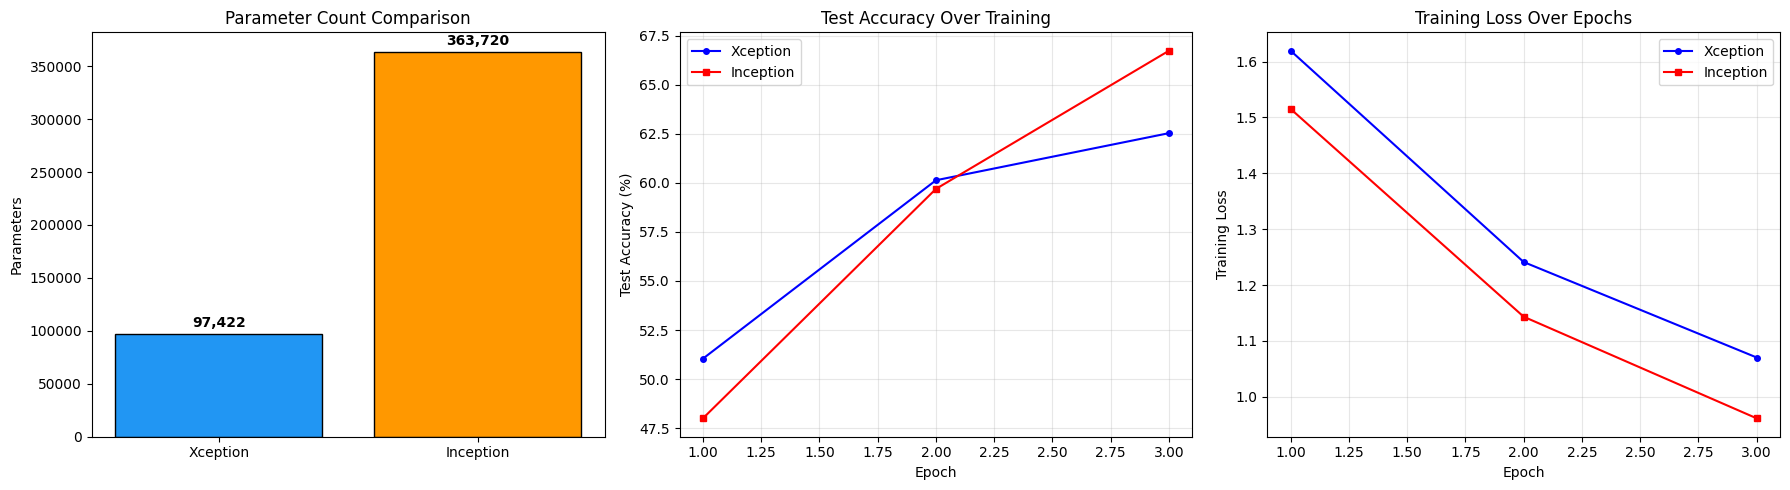

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Parameter count
axes[0].bar(['Xception', 'Inception'], [xception_params, inception_params],
            color=['#2196F3', '#FF9800'], edgecolor='black')
axes[0].set_ylabel('Parameters')
axes[0].set_title('Parameter Count Comparison')
for i, v in enumerate([xception_params, inception_params]):
    axes[0].text(i, v + max(xception_params, inception_params)*0.01, f'{v:,}',
                ha='center', va='bottom', fontweight='bold')

# Test accuracy curves
epochs_range = range(1, len(xception_history['test_acc']) + 1)
axes[1].plot(epochs_range, xception_history['test_acc'], 'b-o', label='Xception', markersize=4)
axes[1].plot(epochs_range, inception_history['test_acc'], 'r-s', label='Inception', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Training loss curves
axes[2].plot(epochs_range, xception_history['train_loss'], 'b-o', label='Xception', markersize=4)
axes[2].plot(epochs_range, inception_history['train_loss'], 'r-s', label='Inception', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Training Loss')
axes[2].set_title('Training Loss Over Epochs')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xception_vs_inception_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Final comparison table
print('=' * 60)
print(f'{"Model":<20} {"Parameters":>12} {"Final Train Acc":>16} {"Final Test Acc":>15}')
print('=' * 60)
print(f'{"SmallXception":<20} {xception_params:>12,} {xception_history["train_acc"][-1]:>15.2f}% {xception_history["test_acc"][-1]:>14.2f}%')
print(f'{"SmallInceptionNet":<20} {inception_params:>12,} {inception_history["train_acc"][-1]:>15.2f}% {inception_history["test_acc"][-1]:>14.2f}%')
print('=' * 60)
print()
acc_diff = xception_history['test_acc'][-1] - inception_history['test_acc'][-1]
param_diff = inception_params - xception_params
print(f'Xception test accuracy advantage: {acc_diff:+.2f}%')
print(f'Parameter difference (Inception - Xception): {param_diff:+,}')
print(f'Xception uses {param_diff/inception_params*100:.1f}% {"fewer" if param_diff > 0 else "more"} parameters than Inception-style')

Model                  Parameters  Final Train Acc  Final Test Acc
SmallXception              97,422           62.16%          62.53%
SmallInceptionNet         363,720           66.96%          66.73%

Xception test accuracy advantage: -4.20%
Parameter difference (Inception - Xception): +266,298
Xception uses 73.2% fewer parameters than Inception-style


## 11. Architecture Summary

### Key Takeaways

1. **The Convolution Spectrum:** Regular convolution (1 segment) → Inception (3–4 segments) → Depthwise separable (N segments, one per channel). Xception pushes to the extreme end.

2. **No Intermediate Non-Linearity:** The most surprising finding — omitting ReLU between depthwise and pointwise operations yields better performance. For 1-channel-deep intermediate feature spaces, non-linearities appear to destroy information.

3. **Residual Connections are Essential:** The paper (Figure 9) shows that without residual connections, Xception converges much slower and to worse accuracy. The residual skip provides gradient flow through the depthwise separable stack.

4. **Efficiency at Equal Capacity:** Xception and Inception V3 have nearly the same parameter count (~22.8M vs ~23.6M), but Xception's gains come from more efficient parameter use — completely decoupled spatial and channel processing.

5. **Scalability:** The accuracy advantage grows with dataset scale — marginal on ImageNet (0.8% top-1) but significant on JFT (4.3% relative), suggesting that decoupled processing becomes more valuable as the task complexity increases.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
